In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/creditcard.csv')

In [3]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


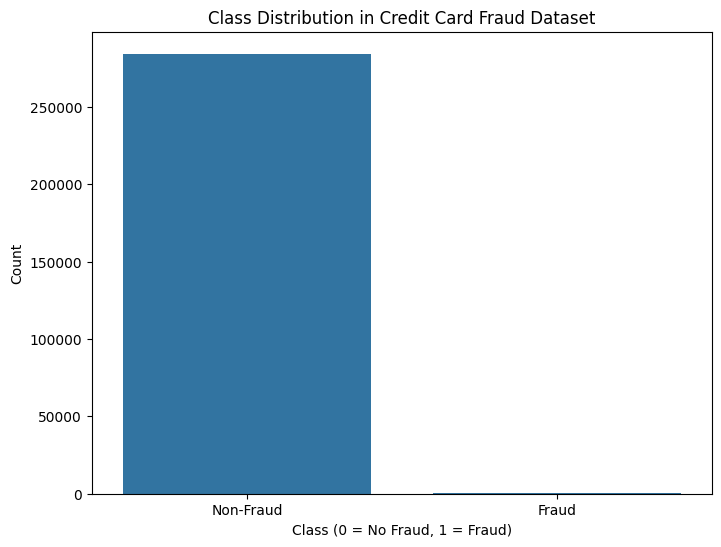

In [8]:
plt.figure(figsize=(8, 6))
sns.barplot(x=df['Class'].value_counts().index, y=df['Class'].value_counts().values)
plt.title('Class Distribution in Credit Card Fraud Dataset')
plt.xlabel('Class (0 = No Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)


In [16]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [18]:
y_pred = knn.predict(X_test)

In [19]:

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[85285    10]
 [   39   109]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.92      0.74      0.82       148

    accuracy                           1.00     85443
   macro avg       0.96      0.87      0.91     85443
weighted avg       1.00      1.00      1.00     85443


Accuracy: 0.9994265182636377


In [20]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Balanced Class Distribution (Oversampling):")
print(pd.Series(y_train_ros).value_counts())


Balanced Class Distribution (Oversampling):
Class
0    199020
1    199020
Name: count, dtype: int64


In [21]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Balanced Class Distribution (Undersampling):")
print(pd.Series(y_train_rus).value_counts())


Balanced Class Distribution (Undersampling):
Class
0    344
1    344
Name: count, dtype: int64


In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Balanced Class Distribution (SMOTE):")
print(pd.Series(y_train_smote).value_counts())


Balanced Class Distribution (SMOTE):
Class
0    199020
1    199020
Name: count, dtype: int64


In [24]:
knn_ros = KNeighborsClassifier(n_neighbors=5)
knn_ros.fit(X_train_ros, y_train_ros)
y_pred_ros = knn_ros.predict(X_test)

print("KNN with Random Over-Sampling:")
print("\nAccuracy:", accuracy_score(y_test, y_pred_ros))


KNN with Random Over-Sampling:

Accuracy: 0.9990285921608558


In [25]:
knn_rus = KNeighborsClassifier(n_neighbors=5)
knn_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = knn_rus.predict(X_test)

print("KNN with Random Under-Sampling:")
print(classification_report(y_test, y_pred_rus))


KNN with Random Under-Sampling:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.86      0.14       148

    accuracy                           0.98     85443
   macro avg       0.54      0.92      0.56     85443
weighted avg       1.00      0.98      0.99     85443



In [26]:
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = knn_smote.predict(X_test)

print("KNN with SMOTE:")
print(classification_report(y_test, y_pred_smote))


KNN with SMOTE:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.48      0.83      0.61       148

    accuracy                           1.00     85443
   macro avg       0.74      0.91      0.80     85443
weighted avg       1.00      1.00      1.00     85443



In [27]:
print("Original Data Accuracy:", accuracy_score(y_test, y_pred))
print("Oversampling Accuracy:", accuracy_score(y_test, y_pred_ros))
print("Undersampling Accuracy:", accuracy_score(y_test, y_pred_rus))
print("SMOTE Accuracy:", accuracy_score(y_test, y_pred_smote))


Original Data Accuracy: 0.9994265182636377
Oversampling Accuracy: 0.9990285921608558
Undersampling Accuracy: 0.9810985101178563
SMOTE Accuracy: 0.9981274065751436
